# Phase 1 — Exploratory Data Analysis (USA / gold 24K / USD / 2017 → today)

Maps 1:1 to the Phase-1 checklist in `refactor/02-data-understanding.md` and `project_plan.md`.

Scope is locked:
- Target metal/karat: **gold 24K** only (other karats and silver are excluded from analysis).
- Country: **USA** only.
- Currency: **USD**.
- Period: **2017-01-01 → today**.

Sections:
0. Setup
1. Trend visualization
2. Correlation matrix vs all exogenous features
3. Stationarity (ADF / KPSS) on level, first difference, log-returns
4. STL decomposition (trend + seasonality + residual)
5. Geopolitical spikes vs gold-price moves
6. Missing-value analysis + imputation strategy

**Phase-2 hand-off:** column-name oddities in the live DB (`cleaned_data` instead of `cleaned_prices`, `"Pays"` instead of `country`, `"Macroeconomic_data"` quoted with mixed-case columns, `"Date"` and `oil` in `vix_oil_data`) are surfaced here but **not fixed in this notebook**. They are Phase-2 cleanup per `refactor/03-data-preparation.md`.

In [4]:
import sys, pathlib
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import STL
from db_settings import get_engine
warnings.filterwarnings('ignore')

## 0. Setup

In [5]:
# Add repo root to sys.path so we can reuse database.get_engine()
REPO_ROOT = pathlib.Path.cwd().parent if pathlib.Path.cwd().name == 'notebooks' else pathlib.Path.cwd()
sys.path.insert(0, str(REPO_ROOT))
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

# Scope constants from project_plan.md
DATE_START = pd.Timestamp('2016-01-01')
DATE_END = pd.Timestamp.today().normalize()
COUNTRY_ISO3 = 'USA'        # value used in gdelt_data.country and reserves_gold.country_code

# Feature lists (from project_plan.md — authoritative)
MACRO_FEATURES = ['fed_rate', 'real_rate', 'cpi', 'gdp', 'dxy', 'unemployment']
MARKET_FEATURES = ['vix', 'oil_price']
GEO_FEATURES = ['total_events', 'political_events', 'war_intensity', 'crisis_index', 'political_pressure']
RESERVE_FEATURE = ['gold_reserves']
ALL_EXOG_FEATURES = MACRO_FEATURES + MARKET_FEATURES + GEO_FEATURES + RESERVE_FEATURE

engine = get_engine()
print(f'Scope: {COUNTRY_ISO3} / gold_24k / USD / {DATE_START.date()} → {DATE_END.date()}')
print(f'Exogenous features ({len(ALL_EXOG_FEATURES)}): {ALL_EXOG_FEATURES}')

Scope: USA / gold_24k / USD / 2016-01-01 → 2026-05-25
Exogenous features (14): ['fed_rate', 'real_rate', 'cpi', 'gdp', 'dxy', 'unemployment', 'vix', 'oil_price', 'total_events', 'political_events', 'war_intensity', 'crisis_index', 'political_pressure', 'gold_reserves']


### 0a. Load USA gold price series

`cleaned_data` (DB-bug name for `cleaned_prices`) uses `"Pays"` for country (French slug) and `date` as **TEXT**. We cast in-memory; the DB-level fix happens in Phase 2. We keep only `gold_24k`.

In [6]:
price_raw = pd.read_sql(
    """
    SELECT date, gold_24k
    FROM raw_prices
    WHERE devise = %(devise)s
    """,
    engine,
    params={
        'devise': 'USD'
    },
)
print(f'Raw USA gold rows: {len(price_raw):,}')
price_raw['date'] = pd.to_datetime(price_raw['date'], errors='coerce')

# Drop bogus rows (gold_24k = 0 or NaN)
before = len(price_raw)
before

# Dedupe by date — if multiple rows per date, keep the median (defensive)
price = price_raw.groupby('date', as_index=False)['gold_24k'].median().sort_values('date').reset_index(drop=True)
print(f'After dedup by date: {len(price):,} rows')
print(f'Date span: {price["date"].min().date()} → {price["date"].max().date()}')
price['gold_24k'].describe()

Raw USA gold rows: 2,448
After dedup by date: 2,448 rows
Date span: 2017-01-02 → 2026-05-22


count    2448.000000
mean       64.910176
std        28.245006
min        36.982000
25%        43.128750
50%        58.150500
75%        65.460500
max       173.620000
Name: gold_24k, dtype: float64

In [7]:
# USD plausibility sanity check (24K spot ≈ $40–$90/g across 2017→2026)
median_price = price['gold_24k'].median()
print(f'Median gold_24k = {median_price:.2f} (expected band 40–90 USD/g)')
if not (20 <= median_price <= 120):
    raise ValueError(f'gold_24k median {median_price:.2f} outside USD band — currency assumption broken')
print('✓ USD assumption looks plausible')

Median gold_24k = 58.15 (expected band 40–90 USD/g)
✓ USD assumption looks plausible


In [8]:
price_raw.head(10)

,date,gold_24k
0,2017-02-23,40.167
1,2017-01-02,36.982
2,2017-01-03,37.206
3,2017-01-04,37.453
4,2017-01-05,37.969
5,2017-01-06,37.694
6,2017-01-09,38.023
7,2017-01-10,38.136
8,2017-01-11,38.380
9,2017-01-12,38.462


### 0b. Load exogenous tables (USA scope)

In [9]:
# Macro (FRED, monthly) -- live table name is `Macroeconomic_data` (quoted); cols are mixed case.
macro = pd.read_sql(
    'SELECT date, fed_rate, real_rate, "CPI" AS cpi, "GDP" AS gdp, '
    '"DXY" AS dxy, "Unemployment" AS unemployment '
    'FROM "macro_data" WHERE date >= %(d)s AND date <= %(e)s ORDER BY date',
    engine,
    params={'d': DATE_START, 'e': DATE_END},
)
macro['date'] = pd.to_datetime(macro['date'])
# Dedupe: live `Macroeconomic_data` contains each row TWICE (FRED loader ran twice).
# Phase-2 cleanup fixes this at the DB level; for EDA we dedupe in-memory.
_before = len(macro)
macro = macro.drop_duplicates(subset='date', keep='first').sort_values('date').reset_index(drop=True)
print(f'Macro rows: {len(macro):,}  (dropped {_before - len(macro):,} duplicates)  '
      f'{macro["date"].min().date()} -> {macro["date"].max().date()}')
macro.head()

Macro rows: 2,741  (dropped 0 duplicates)  2016-01-01 -> 2026-05-15


,date,fed_rate,real_rate,cpi,gdp,dxy,unemployment
0,2016-01-01,0.34,0.734506,237.652,18525.933,NaN,4.8
1,2016-01-04,NaN,NaN,NaN,NaN,114.1595,NaN
2,2016-01-05,NaN,NaN,NaN,NaN,114.2649,NaN
3,2016-01-06,NaN,NaN,NaN,NaN,114.6177,NaN
4,2016-01-07,NaN,NaN,NaN,NaN,114.6516,NaN


In [10]:
# Market (Yahoo, daily) -- live cols are `"Date"` and `oil` (not `oil_price`).
market = pd.read_sql(
    'SELECT "Date" AS date, vix, oil AS oil_price FROM vix_oil_data '
    'WHERE "Date" >= %(d)s AND "Date" <= %(e)s ORDER BY "Date"',
    engine,
    params={'d': DATE_START, 'e': DATE_END},
)
market['date'] = pd.to_datetime(market['date'])
# Defensive dedupe (currently clean; protects against re-ingestion in future).
market = market.drop_duplicates(subset='date', keep='first').sort_values('date').reset_index(drop=True)
print(f'Market rows: {len(market):,}  {market["date"].min().date()} -> {market["date"].max().date()}')
market.head()

Market rows: 2,615  2016-01-04 -> 2026-05-25


,date,vix,oil_price
0,2016-01-04,20.700001,36.759998
1,2016-01-05,19.340000,35.970001
2,2016-01-06,20.590000,33.970001
3,2016-01-07,24.990000,33.270000
4,2016-01-08,27.010000,33.160000


In [11]:
# Geopolitical (GDELT, daily) -- live table name is `gdelt_data`.
geo = pd.read_sql(
    'SELECT date, total_events, political_events, war_intensity, crisis_index, political_pressure '
    'FROM geopo_data WHERE country = %(c)s AND date >= %(d)s AND date <= %(e)s ORDER BY date',
    engine,
    params={'c': COUNTRY_ISO3, 'd': DATE_START.date(), 'e': DATE_END.date()},
)
geo['date'] = pd.to_datetime(geo['date'])
# Defensive dedupe (currently clean; protects against re-ingestion in future).
geo = geo.drop_duplicates(subset='date', keep='first').sort_values('date').reset_index(drop=True)
print(f'Geo rows: {len(geo):,}  {geo["date"].min().date()} -> {geo["date"].max().date()}')
geo.head()

Geo rows: 3,797  2016-01-01 -> 2026-05-24


,date,total_events,political_events,war_intensity,crisis_index,political_pressure
0,2016-01-01,19589,5406,0.082087,0.319644,0.275971
1,2016-01-02,16265,4194,0.076606,0.435942,0.257854
2,2016-01-03,16740,4351,0.073716,0.350119,0.259916
3,2016-01-04,29041,7509,0.064254,0.479398,0.258565
4,2016-01-05,36073,9900,0.072353,0.301184,0.274443


In [12]:
# Reserves (World Bank, annual) — annual rows; will be forward-filled to daily in-memory below.
reserves = pd.read_sql(
    "SELECT year, value AS gold_reserves FROM reserves_gold WHERE country_code = %(c)s ORDER BY year",
    engine,
    params={'c': COUNTRY_ISO3},
)
print(f'Reserves rows: {len(reserves):,}  {reserves["year"].min()} → {reserves["year"].max()}')
reserves

Reserves rows: 15  2010 → 2024


,year,gold_reserves
0,2010,488928508742
1,2011,537267041107
2,2012,574268084132
3,2013,448508920737
4,2014,434416188744
5,2015,383728497570
6,2016,405942428719
7,2017,451285263406
8,2018,449907088828
9,2019,516700583371


## 1. Gold 24K price trend (USA, 2017 → today)

Task 1 from `project_plan.md` PHASE 1.

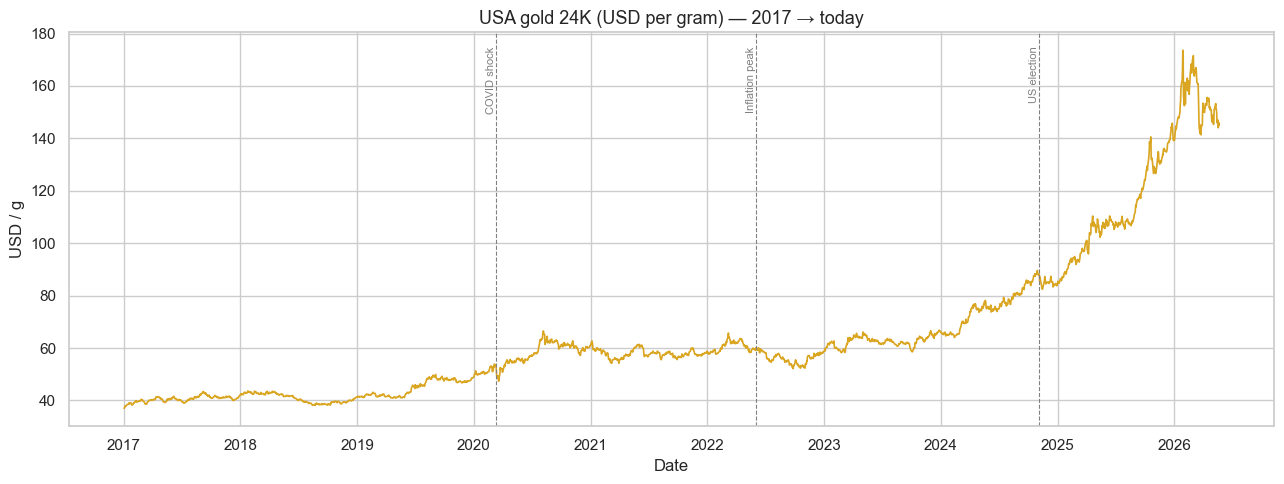

Min: 36.98   Max: 173.62   Range start→end: 36.98 → 144.99 USD/g


In [31]:
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(price['date'], price['gold_24k'], lw=1.2, color='goldenrod')
ax.set_title('USA gold 24K (USD per gram) — 2017 → today', fontsize=13)
ax.set_xlabel('Date'); ax.set_ylabel('USD / g')
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
# Reference regime shifts
events = {
    '2020-03-11': 'COVID shock',
    '2022-06-02': 'Inflation peak',
    '2024-11-05': 'US election',
}
for d, label in events.items():
    ts = pd.Timestamp(d)
    if price['date'].min() <= ts <= price['date'].max():
        ax.axvline(ts, ls='--', color='gray', lw=0.8)
        ax.text(ts, ax.get_ylim()[1]*0.97, label, rotation=90, va='top', ha='right', fontsize=8, color='gray')
plt.tight_layout(); plt.show()
print(f'Min: {price["gold_24k"].min():.2f}   Max: {price["gold_24k"].max():.2f}   '
      f'Range start→end: {price["gold_24k"].iloc[0]:.2f} → {price["gold_24k"].iloc[-1]:.2f} USD/g')

**Verdict — Task 1**: read the trend chart above and note: overall direction (up / flat / down), notable drawdowns or rallies aligned with the marked regime events, and any obvious outliers worth investigating in Phase 2 cleanup.

## 2. Correlation matrix — `gold_24k` vs all exogenous features

Task 2 from `project_plan.md` PHASE 1. We forward-fill monthly macro and annual reserves **in-memory only** (no DB writes — Phase 2 owns persisted forward-fill).

In [18]:
# Build a daily calendar covering the price span
daily = pd.DataFrame({'date': pd.date_range(price['date'].min(), price['date'].max(), freq='D')})
wide = daily.merge(price, on='date', how='left')
# Forward-fill the gold price across weekend/holiday gaps (decision locked in refactor/02 § Decisions)
wide['gold_24k'] = wide['gold_24k'].ffill()

# Macro — monthly → ffill to daily
wide = wide.merge(macro, on='date', how='left')
for c in MACRO_FEATURES:
    wide[c] = wide[c].ffill()

# Market — daily, ffill weekend/holiday gaps
wide = wide.merge(market[['date'] + MARKET_FEATURES], on='date', how='left')
for c in MARKET_FEATURES:
    wide[c] = wide[c].ffill()

# Geo — daily
wide = wide.merge(geo[['date'] + GEO_FEATURES], on='date', how='left')
for c in GEO_FEATURES:
    wide[c] = wide[c].ffill()

# Reserves — annual → ffill via year join
wide['year'] = wide['date'].dt.year
wide = wide.merge(reserves, on='year', how='left')
wide['gold_reserves'] = wide['gold_reserves'].ffill()
wide = wide.drop(columns=['year'])

print(f'Wide frame shape: {wide.shape}')
print(f'Null counts (top 10):')
print(wide.isna().sum().sort_values(ascending=False).head(10))
wide.head(3)

Wide frame shape: (3428, 17)
Null counts (top 10):
date_y          507
gdp              89
unemployment     30
cpi              30
fed_rate         30
real_rate        30
oil_price         1
vix               1
dxy               1
date_x            0
dtype: int64


,date_x,gold_24k,fed_rate,real_rate,cpi,gdp,dxy,unemployment,vix,oil_price,total_events,political_events,war_intensity,crisis_index,political_pressure,gold_reserves,date_y
0,2017-01-02,36.982,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20249,5386,0.077140,0.390093,0.265988,4.512853e+11,2017-01-01
1,2017-01-03,37.206,NaN,NaN,NaN,NaN,119.0903,NaN,12.85,52.330002,30739,7913,0.068577,0.495553,0.257425,4.512853e+11,2017-01-01
2,2017-01-04,37.453,NaN,NaN,NaN,NaN,118.8803,NaN,11.85,53.259998,37087,9416,0.061342,0.588503,0.253890,4.512853e+11,2017-01-01


In [19]:
# Drop the warm-up window (initial rows where some ffill targets are still NaN)
import jinja2
wide_clean = wide.dropna(subset=ALL_EXOG_FEATURES + ['gold_24k']).reset_index(drop=True)

# Pearson + Spearman correlation of each exog with gold_24k
rows = []
for c in ALL_EXOG_FEATURES:
    pearson_r, pearson_p = stats.pearsonr(wide_clean['gold_24k'], wide_clean[c])
    spear_r, spear_p = stats.spearmanr(wide_clean['gold_24k'], wide_clean[c])
    rows.append({'feature': c, 'pearson': pearson_r, 'pearson_p': pearson_p,
                 'spearman': spear_r, 'spearman_p': spear_p})
corr_df = pd.DataFrame(rows).sort_values('pearson', key=abs, ascending=False).reset_index(drop=True)
corr_df.style.background_gradient(subset=['pearson', 'spearman'], cmap='RdBu_r', vmin=-1, vmax=1)

,feature,pearson,pearson_p,spearman,spearman_p
0,gdp,0.825554,0.000000,0.918082,0.000000
1,cpi,0.807344,0.000000,0.941902,0.000000
2,gold_reserves,0.782137,0.000000,0.934830,0.000000
3,dxy,0.462729,0.000000,0.623121,0.000000
4,fed_rate,0.454841,0.000000,0.490736,0.000000
5,real_rate,0.441992,0.000000,0.485012,0.000000
6,total_events,-0.310426,0.000000,-0.368797,0.000000
7,political_events,-0.278261,0.000000,-0.338460,0.000000
8,oil_price,0.221162,0.000000,0.384508,0.000000
9,political_pressure,0.189584,0.000000,0.182783,0.000000


In [20]:
wide_clean.head()

,date_x,gold_24k,fed_rate,real_rate,cpi,gdp,dxy,unemployment,vix,oil_price,total_events,political_events,war_intensity,crisis_index,political_pressure,gold_reserves,date_y
0,2017-04-01,40.159,0.9,0.765754,244.193,19438.643,114.7938,4.4,12.37,50.599998,23186,5590,0.052359,0.660429,0.241094,4.512853e+11,2017-01-01
1,2017-04-02,40.159,0.9,0.765754,244.193,19438.643,114.7938,4.4,12.37,50.599998,18450,4401,0.056531,0.644949,0.238537,4.512853e+11,2017-01-01
2,2017-04-03,40.365,0.9,0.765754,244.193,19438.643,114.8734,4.4,12.38,50.240002,33483,8471,0.063883,0.572673,0.252994,4.512853e+11,2017-01-01
3,2017-04-04,40.368,0.9,0.765754,244.193,19438.643,115.0038,4.4,11.79,51.029999,38237,9701,0.055522,0.597662,0.253707,4.512853e+11,2017-01-01
4,2017-04-05,40.460,0.9,0.765754,244.193,19438.643,114.9494,4.4,12.89,51.150002,41158,10366,0.058142,0.586044,0.251859,4.512853e+11,2017-01-01


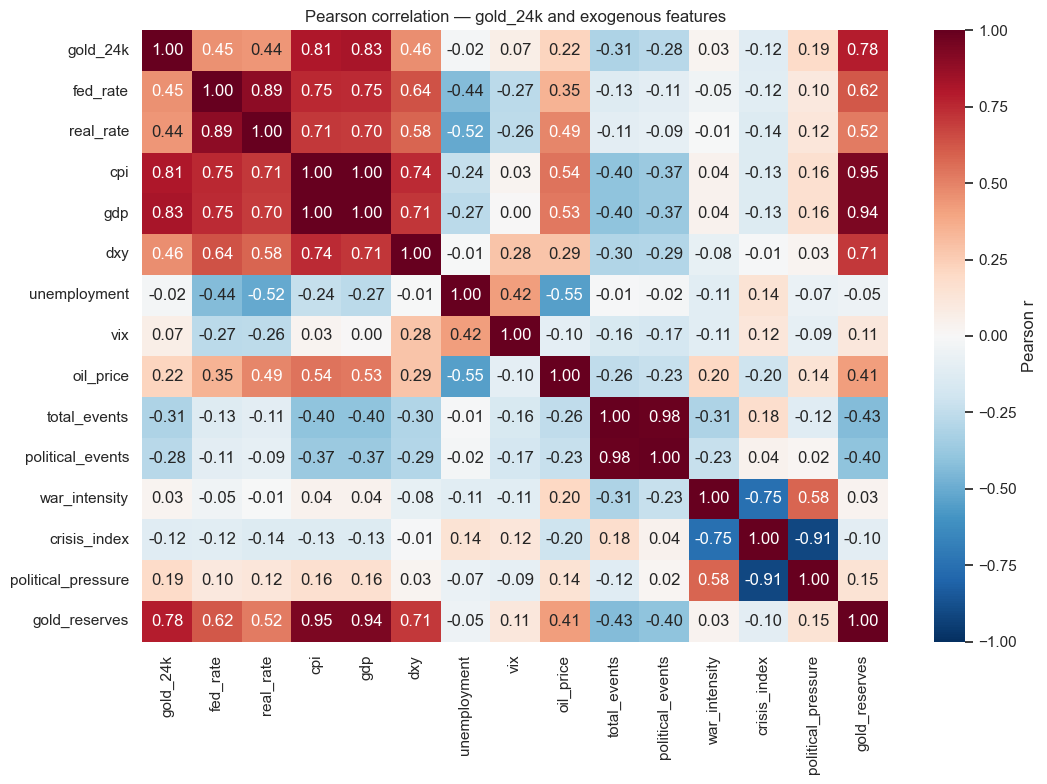

In [21]:
# Full correlation heatmap (all features + gold_24k)
cm = wide_clean[['gold_24k'] + ALL_EXOG_FEATURES].corr()
fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(cm, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            cbar_kws={'label': 'Pearson r'}, ax=ax)
ax.set_title('Pearson correlation — gold_24k and exogenous features', fontsize=12)
plt.tight_layout(); plt.show()

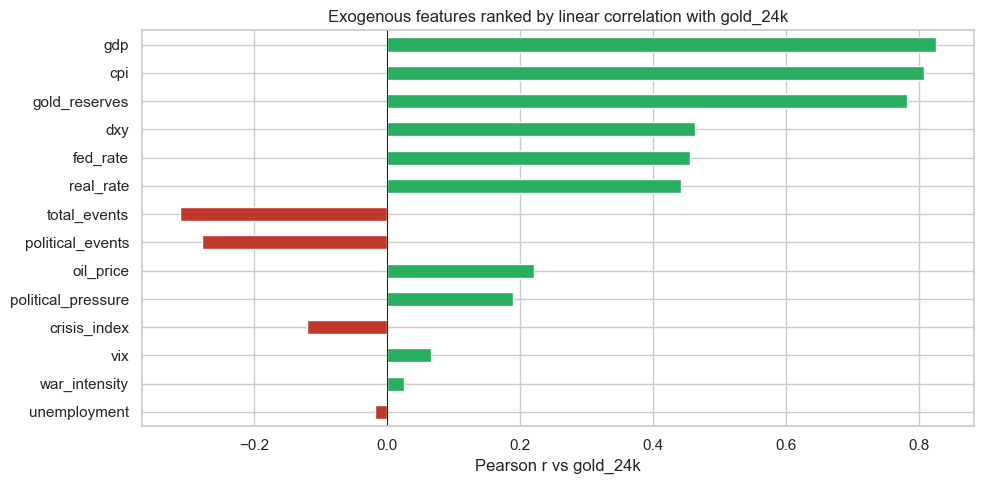

In [22]:
# Ranked bar chart of |Pearson r| vs gold_24k
fig, ax = plt.subplots(figsize=(10, 5))
ranked = corr_df.set_index('feature')['pearson']
colors = ['#c0392b' if v < 0 else '#27ae60' for v in ranked]
ranked.plot(kind='barh', ax=ax, color=colors)
ax.axvline(0, color='black', lw=0.6)
ax.set_xlabel('Pearson r vs gold_24k'); ax.set_ylabel('')
ax.set_title('Exogenous features ranked by linear correlation with gold_24k')
ax.invert_yaxis()
plt.tight_layout(); plt.show()

**Verdict — Task 2**: list the top 3 |ρ| features (likely candidates for SHAP-confirmed importance in Phase 3) and call out any with |ρ| < 0.1 that could be dropped to reduce noise (though we'll keep them in `ml.us_gold_features_daily` per the project_plan spec).

## 3. Stationarity — ADF + KPSS on level, first difference, log-returns

Task 3 from `project_plan.md` PHASE 1. Both tests run on three transformations to find a transformation where ADF rejects a unit root **and** KPSS does not reject stationarity.

In [23]:
y = wide_clean.set_index('date_x')['gold_24k'].astype(float)
transforms = {
    'level':        y,
    'first_diff':   y.diff().dropna(),
    'log_returns':  np.log(y / y.shift(1)).dropna(),
}

def adf_kpss(series):
    adf_stat, adf_p, *_ = adfuller(series, autolag='AIC')
    # KPSS warns; suppress
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        kpss_stat, kpss_p, *_ = kpss(series, regression='c', nlags='auto')
    return adf_stat, adf_p, kpss_stat, kpss_p

rows = []
for name, s in transforms.items():
    a_stat, a_p, k_stat, k_p = adf_kpss(s)
    rows.append({
        'transform': name,
        'ADF stat': a_stat, 'ADF p': a_p,
        'ADF says': 'stationary' if a_p < 0.05 else 'non-stationary',
        'KPSS stat': k_stat, 'KPSS p': k_p,
        'KPSS says': 'stationary' if k_p > 0.05 else 'non-stationary',
    })
stat_df = pd.DataFrame(rows)
stat_df

,transform,ADF stat,ADF p,ADF says,KPSS stat,KPSS p,KPSS says
0,level,2.698225,9.990869e-01,non-stationary,6.116108,0.010000,non-stationary
1,first_diff,-13.007717,2.606627e-24,stationary,0.549063,0.030616,non-stationary
2,log_returns,-12.410929,4.345456e-23,stationary,0.334030,0.100000,stationary


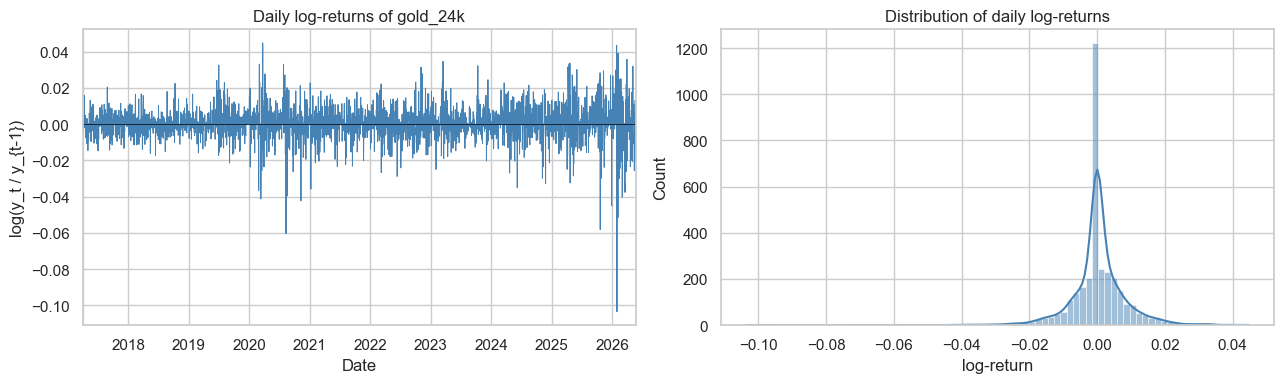

In [24]:
# Visualize the log-returns distribution (typical modeling target for ARIMA on log-prices)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
transforms['log_returns'].plot(ax=axes[0], color='steelblue', lw=0.7)
axes[0].axhline(0, color='black', lw=0.5)
axes[0].set_title('Daily log-returns of gold_24k')
axes[0].set_xlabel('Date'); axes[0].set_ylabel('log(y_t / y_{t-1})')

sns.histplot(transforms['log_returns'], kde=True, bins=80, ax=axes[1], color='steelblue')
axes[1].set_title('Distribution of daily log-returns')
axes[1].set_xlabel('log-return')
plt.tight_layout(); plt.show()

**Verdict — Task 3**: pick the transform where both tests agree on stationary (typically `log_returns` for asset prices). This is the modeling target for ARIMA/SARIMA in Phase 3.

## 4. STL decomposition

Task 4 from `project_plan.md` PHASE 1. Period = 365 (daily series, calendar year).

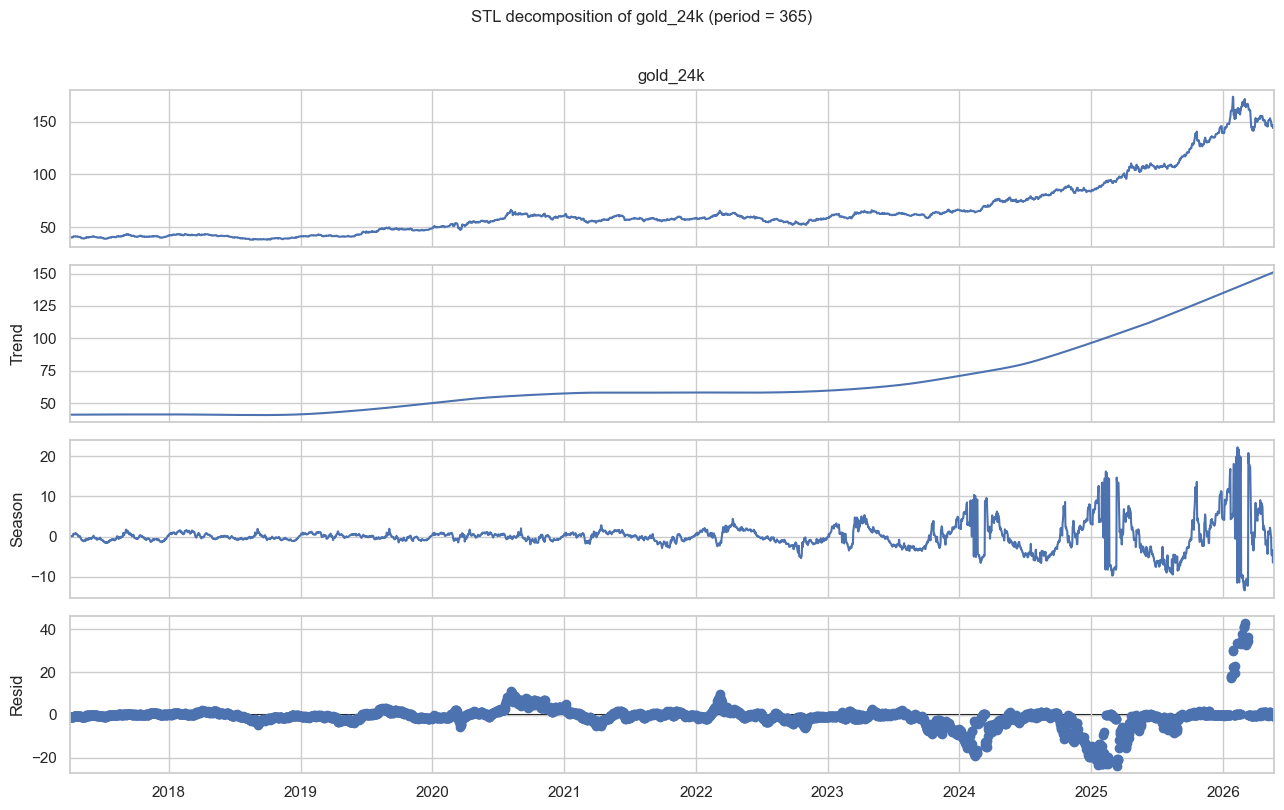

Component standard deviations:
trend       27.553642
seasonal     3.453491
residual     5.225235
dtype: float64

Seasonal range: -13.39 → 22.20 USD/g
Trend range:    40.87 → 151.17 USD/g


In [25]:
stl = STL(y, period=365, robust=True).fit()
fig = stl.plot()
fig.set_size_inches(13, 8)
fig.suptitle('STL decomposition of gold_24k (period = 365)', fontsize=12, y=1.01)
plt.tight_layout(); plt.show()

# Quantify component magnitudes
components = pd.DataFrame({'trend': stl.trend, 'seasonal': stl.seasonal, 'residual': stl.resid})
print('Component standard deviations:')
print(components.std())
print(f'\nSeasonal range: {components["seasonal"].min():.2f} → {components["seasonal"].max():.2f} USD/g')
print(f'Trend range:    {components["trend"].min():.2f} → {components["trend"].max():.2f} USD/g')

**Verdict — Task 4**: compare the std of trend vs seasonal vs residual. For gold, trend usually dominates; seasonal amplitude is typically small relative to the trend's swing. Note whether the seasonal pattern is strong enough to warrant SARIMA over plain ARIMA in Phase 3.

## 5. Geopolitical event spikes vs gold-price moves

Task 5 from `project_plan.md` PHASE 1. A "spike" = day where USA `crisis_index` exceeds its 99th percentile across the window.

Crisis-index 99th pct = 0.975   |   War-intensity 99th pct = 0.102
Spike days identified: 68


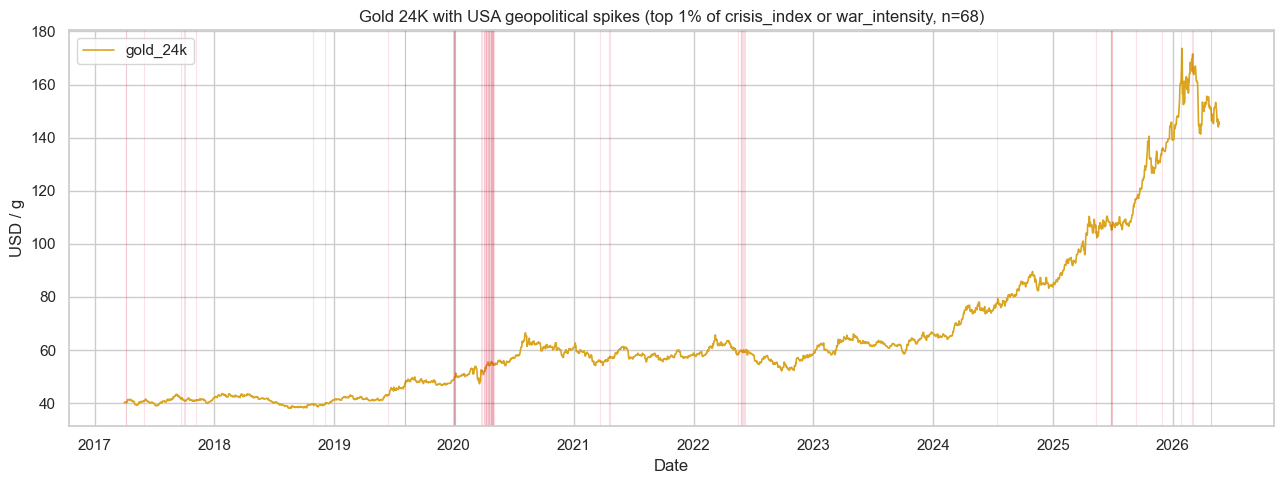

In [26]:
geo_window = wide_clean[['date_x', 'crisis_index', 'war_intensity']].copy()
thresh_crisis = geo_window['crisis_index'].quantile(0.99)
thresh_war = geo_window['war_intensity'].quantile(0.99)
spikes = geo_window[(geo_window['crisis_index'] >= thresh_crisis) |
                    (geo_window['war_intensity'] >= thresh_war)].copy()
print(f'Crisis-index 99th pct = {thresh_crisis:.3f}   |   War-intensity 99th pct = {thresh_war:.3f}')
print(f'Spike days identified: {len(spikes):,}')

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(wide_clean['date_x'], wide_clean['gold_24k'], color='goldenrod', lw=1.2, label='gold_24k')
for d in spikes['date_x']:
    ax.axvline(d, color='crimson', alpha=0.12, lw=0.8)
ax.set_title(f'Gold 24K with USA geopolitical spikes (top 1% of crisis_index or war_intensity, n={len(spikes)})')
ax.set_xlabel('Date'); ax.set_ylabel('USD / g')
ax.legend(loc='upper left')
plt.tight_layout(); plt.show()

In [27]:
# Compare 7-day forward return after a spike vs baseline
# Build a uniquely-indexed price series (defensive against any residual dupes upstream).
p = (wide_clean[['date_x', 'gold_24k']]
     .drop_duplicates(subset='date_x', keep='last')
     .set_index('date_x')['gold_24k'])
fwd_ret_7 = (p.shift(-7) / p - 1) * 100

spike_dates = pd.DatetimeIndex(spikes['date_x'].unique()).intersection(fwd_ret_7.index)
ret_after_spike = fwd_ret_7.loc[spike_dates].dropna()
ret_baseline = fwd_ret_7.dropna()

print(f'7-day forward return AFTER a spike:   mean {ret_after_spike.mean():+.2f}%   '
      f'median {ret_after_spike.median():+.2f}%   n={len(ret_after_spike)}')
print(f'7-day forward return baseline (all):  mean {ret_baseline.mean():+.2f}%      '
      f'median {ret_baseline.median():+.2f}%      n={len(ret_baseline)}')

from scipy.stats import mannwhitneyu
if len(ret_after_spike) > 0:
    u_stat, u_p = mannwhitneyu(ret_after_spike, ret_baseline, alternative='greater')
    print(f'Mann-Whitney U (one-sided, after-spike > baseline): U={u_stat:.0f}, p={u_p:.4f}')
else:
    print('No spike dates after intersection -- nothing to test.')

7-day forward return AFTER a spike:   mean +0.55%   median +0.63%   n=68
7-day forward return baseline (all):  mean +0.29%      median +0.31%      n=3332
Mann-Whitney U (one-sided, after-spike > baseline): U=121508, p=0.1525


**Verdict — Task 5**: state whether the post-spike 7-day return is higher than baseline and whether the U test rejects the null at α = 0.05. This is preliminary evidence — Phase 3 SHAP will be the final word on whether geopolitical features actually drive the model.

## 6. Missing-value analysis + imputation strategy

Task 6 from `project_plan.md` PHASE 1. The forward-fill decision for weekend/holiday gold-price gaps is already locked in `refactor/02-data-understanding.md` § Decisions.

In [28]:
# Build a per-source missingness summary on the raw (pre-ffill) frame
raw_frame = (
    pd.DataFrame({'date': pd.date_range(price['date'].min(), price['date'].max(), freq='D')})
    .merge(price, on='date', how='left')
    .merge(macro, on='date', how='left')
    .merge(market[['date'] + MARKET_FEATURES], on='date', how='left')
    .merge(geo[['date'] + GEO_FEATURES], on='date', how='left')
)
raw_frame['year'] = raw_frame['date'].dt.year
raw_frame = raw_frame.merge(reserves, on='year', how='left').drop(columns=['year'])

miss = pd.DataFrame({
    'null_count': raw_frame.drop(columns=['date_x']).isna().sum(),
    'null_pct':   raw_frame.drop(columns=['date_x']).isna().mean() * 100,
}).sort_values('null_pct', ascending=False)
miss

,null_count,null_pct
gdp,3392,98.949825
cpi,3318,96.791132
unemployment,3318,96.791132
fed_rate,3317,96.761960
real_rate,3316,96.732789
dxy,1090,31.796966
vix,1068,31.155193
oil_price,1066,31.096849
gold_24k,980,28.588098
date_y,507,14.789965


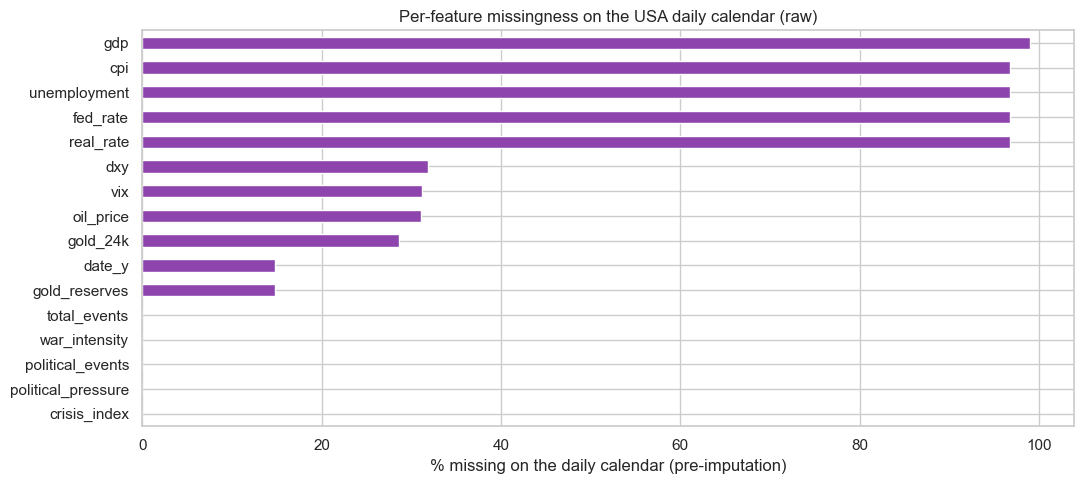

In [29]:
fig, ax = plt.subplots(figsize=(11, 5))
miss['null_pct'].plot(kind='barh', color='#8e44ad', ax=ax)
ax.set_xlabel('% missing on the daily calendar (pre-imputation)')
ax.set_title('Per-feature missingness on the USA daily calendar (raw)')
ax.invert_yaxis()
plt.tight_layout(); plt.show()

In [30]:
# Gold-price-gap profile: distribution of gap lengths in the original (non-resampled) USA series
gaps = price['date'].diff().dt.days.dropna()
gap_summary = gaps.value_counts().sort_index().head(15)
print('Gap-length distribution (days between consecutive USA price observations):')
print(gap_summary.to_string())
print(f'\nMax gap: {gaps.max()} days   |   Median gap: {gaps.median()} days')
print('Gaps of 2–3 days are weekends; longer gaps include US holidays (Thanksgiving, Christmas).')

Gap-length distribution (days between consecutive USA price observations):
date
1.0    1956
2.0       2
3.0     489

Max gap: 3.0 days   |   Median gap: 1.0 days
Gaps of 2–3 days are weekends; longer gaps include US holidays (Thanksgiving, Christmas).


**Verdict — Task 6 (imputation strategy):**

| Source                 | Native grain | Imputation rule (Phase 2)                                  |
|------------------------|--------------|-------------------------------------------------------------|
| `cleaned_prices`       | Daily (gaps) | Forward-fill weekend / holiday gaps                         |
| `macroeconomic_data`   | Monthly      | Forward-fill month → daily                                  |
| `vix_oil_data`         | Daily (gaps) | Forward-fill weekend / holiday gaps                         |
| `geopolitical_data`    | Daily        | Should be dense for USA; ffill any sporadic missing days    |
| `reserves_gold`        | Annual       | Forward-fill year → daily                                   |

This matches the rules in `project_plan.md` and locks the strategy that Phase 2 will implement at the DB / feature-table level.

## Phase-2 hand-off notes (column-name oddities to fix in Data Preparation)

Surfaced by this EDA (do **not** fix here — that's Phase 2 cleanup per `refactor/03-data-preparation.md`):

1. `cleaned_prices` is named **`cleaned_data`** in the DB (insert function mismatch).
2. `cleaned_data.country` is actually **`"Pays"`** (French slug values, mixed case requires quoting). Standardize to ISO3 `country_code`.
3. `cleaned_data."Année"` (accented) — unused for USA modeling but should be normalized.
4. `cleaned_data.date` is **TEXT** — convert to `DATE`.
5. `cleaned_data.devise` is **NULL for `etats-unis`** — won't matter for Stage 1 (USA-only) but flag it.
6. `cleaned_data.gold_24k` contains some 0-valued rows that we filtered out — Phase 2 should add a non-zero / sanity-bound constraint.
7. `geopolitical_data` is named **`gdelt_data`** in the DB.
8. `"Macroeconomic_data"` (quoted, mixed case) — rename to `macroeconomic_data`. Columns `"CPI"`, `"GDP"`, `"DXY"`, `"Unemployment"` should be lowercased to match the DDL in `database.py`.
9. `vix_oil_data."Date"` (quoted, capital D) → `date`. Column `oil` → `oil_price` (DDL already uses `oil_price` but live column is `oil`).
10. `dim_date` lacks `day_of_week` and `is_month_end` columns required by `project_plan.md` `CALENDAR_FEATURES` — derive them in the Phase-2 feature-build step rather than altering the table.
11. Trading-day calendar choice (NYSE business days vs all calendar days forward-filled) is still **open** — pick one in Phase 2 before computing `y_lag_*` / `y_ma_*` / `y_vol_30`.